In [34]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from roboflow import Roboflow

%matplotlib inline

## Part 1: Inference with Pretrained YOLOv8 Model


0: 448x640 1 person, 1 truck, 68.2ms
Speed: 2.2ms preprocess, 68.2ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
Class: person, Confidence: 0.63
Class: truck, Confidence: 0.63


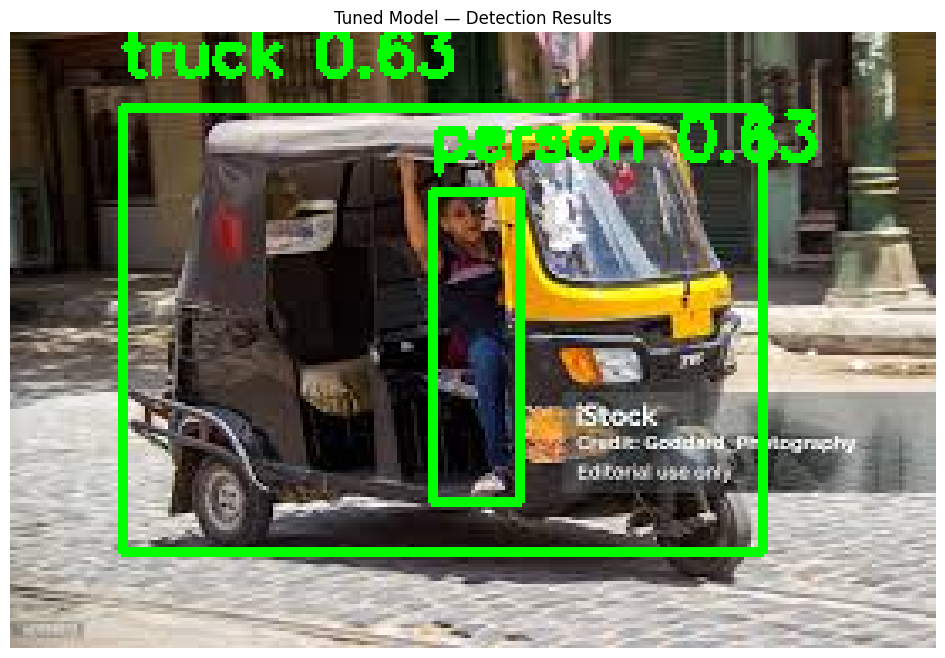

In [35]:
model = YOLO('yolov8n.pt')

image_path = '/home/khaled/Desktop/projects/object_detection_YOLOV8/tuktuk/Pasted image (7).png'

image = cv2.imread(image_path)
results = model(image)

image_rgb = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2RGB)
for box in results[0].boxes:
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    confidence = float(box.conf[0])
    class_name = results[0].names[int(box.cls[0])]

    print(f"Class: {class_name}, Confidence: {confidence:.2f}")
    cv2.rectangle(image_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.putText(image_rgb, f"{class_name} {confidence:.2f}", (int(x1), int(y1) - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis('off')
plt.title('Tuned Model — Detection Results')
plt.show()

> **Note:** The tuktuk was detected as a *truck* — YOLOv8n is trained on COCO which has no "tuktuk" class. We'll fix this by fine-tuning on a custom dataset.

## Part 2: Fine-Tuning on Custom Tuktuk Dataset (Roboflow)

In [22]:

rf = Roboflow(api_key="WLzhDCJWUlphJZ6KCw6P")
project = rf.workspace("khaleds-workspace-ompid").project("my_project-bmbsg")
version = project.version(1)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to my_project-1 in yolov8:: 100%|██████████| 39/39 [00:00<00:00, 5462.97it/s]


## Part 3: Training YOLOv8 on the Custom Dataset

In [43]:
from pathlib import Path

existing_weights = Path('runs/detect/tuktuk_detector/weights/best.pt')
if existing_weights.exists():
    train_model = YOLO(str(existing_weights))
    print(f"Loaded existing weights: {existing_weights}")
else:
    train_model = YOLO('yolov8n.pt')
    print("Starting from pretrained YOLOv8n weights")

results = train_model.train(
    data='/home/khaled/Desktop/projects/object_detection_YOLOV8/my_project-1/data.yaml',
    epochs=200,
    imgsz=640,
    batch=8,
    name='tuktuk_detector',
    patience=30,

    # Geometric augmentations
    degrees=15,          # random rotation ±15°
    translate=0.2,       # random translation ±20%
    scale=0.6,           # random scale 40%→160%
    shear=5.0,           # random shear ±5°
    perspective=0.0005,  # perspective warp
    flipud=0.3,          # vertical flip 30%
    fliplr=0.5,          # horizontal flip 50%

    # Color augmentations
    hsv_h=0.02,          # hue shift
    hsv_s=0.8,           # saturation
    hsv_v=0.5,           # brightness

    # Advanced (most useful with small datasets)
    mosaic=1.0,          # combines 4 images into 1 
    mixup=0.2,           # blend 2 images + labels 
    copy_paste=0.3,      # copy-paste objects between images (0.3 probability)
)

Loaded existing weights: runs/detect/tuktuk_detector/weights/best.pt
Ultralytics 8.4.52 🚀 Python-3.12.3 torch-2.12.0+cu130 CPU (Intel Core i9-9980HK 2.40GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/khaled/Desktop/projects/object_detection_YOLOV8/my_project-1/data.yaml, degrees=15, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=runs/detect/tuktuk_detector/weights/best.pt, 

In [44]:
metrics = train_model.val()

print(f"Precision:  {metrics.box.mp:.3f}")
print(f"Recall:     {metrics.box.mr:.3f}")
print(f"mAP50:      {metrics.box.map50:.3f}")   # IoU threshold = 0.50
print(f"mAP75:      {metrics.box.map75:.3f}")   # IoU threshold = 0.75
print(f"mAP50-95:   {metrics.box.map:.3f}")     # IoU threshold = 0.50 → 0.95

Ultralytics 8.4.52 🚀 Python-3.12.3 torch-2.12.0+cu130 CPU (Intel Core i9-9980HK 2.40GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1677.6±18.4 MB/s, size: 41.0 KB)
val: Scanning /home/khaled/Desktop/projects/object_detection_YOLOV8/my_project-1/valid/labels.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 1.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.0it/s 0.2s
                   all          2          3      0.005          1      0.747      0.529
Speed: 1.8ms preprocess, 79.5ms inference, 0.0ms loss, 11.1ms postprocess per image
Results saved to /home/khaled/Desktop/projects/object_detection_YOLOV8/runs/detect/val-3
Precision:  0.005
Recall:     1.000
mAP50:      0.747
mAP75:      0.747
mAP50-95:   0.529


## Part 4: Inference with the Trained Model

In [ ]:
coco_model   = YOLO('yolov8n.pt')
tuktuk_model = YOLO(str(train_model.trainer.save_dir / 'weights' / 'best.pt'))

test_image = cv2.imread(image_path)
canvas = cv2.cvtColor(test_image.copy(), cv2.COLOR_BGR2RGB)

coco_results   = coco_model(test_image, conf=0.25)
tuktuk_results = tuktuk_model(test_image, conf=0.1)

# COCO detections — blue boxes
for box in coco_results[0].boxes:
    x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
    label = f"{coco_results[0].names[int(box.cls[0])]} {float(box.conf[0]):.2f}"
    cv2.rectangle(canvas, (x1, y1), (x2, y2), (30, 100, 255), 2)
    cv2.rectangle(canvas, (x1, y1 - 20), (x1 + len(label) * 9, y1), (30, 100, 255), -1)
    cv2.putText(canvas, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)
    print(f"[COCO]   {label}")

# TukTuk detections — green boxes
for box in tuktuk_results[0].boxes:
    x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
    label = f"{tuktuk_results[0].names[int(box.cls[0])]} {float(box.conf[0]):.2f}"
    cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 210, 90), 2)
    cv2.rectangle(canvas, (x1, y1 - 20), (x1 + len(label) * 9, y1), (0, 210, 90), -1)
    cv2.putText(canvas, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)
    print(f"[TukTuk] {label}")

if not coco_results[0].boxes and not tuktuk_results[0].boxes:
    print("No detections from either model")

plt.figure(figsize=(12, 8))
plt.imshow(canvas)
plt.axis('off')
plt.title('Blue = COCO (yolov8n)   |   Green = TukTuk (fine-tuned)', fontsize=13)
plt.show()

In [ ]:
output_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
output_path = 'output.jpg'
cv2.imwrite(output_path, output_image)
print(f"Saved annotated image to {output_path}")